## Run this and wait for the files to be fully generated on the first run or if using another generator than version 1

In [1]:
# Run if no data, this is the specific data for this file
#from datapreparation.mockdata import trial_generate_real
#
# trial_generate_real.main(plants_per_user=3,
#         readings_per_plant=10_000,
#         days_of_data=1000,
#         waterings_per_plant=10_00,
#         watering_threshold_percent=0.70)

In [2]:
import pandas as pd
path = "mockdata/"

df_waterings = pd.read_csv(f'{path}waterings.csv')
df_waterings = df_waterings.drop(columns=['PredictedFutureWaterTime'])
df_sensors = pd.read_csv(f'{path}sensor_datas.csv')
df_plants = pd.read_csv(f'{path}plants.csv')
df_sensors

,PlantMAC,Temperature,AirHumidity,SoilHumidity,LightIntensity,Timestamp
0,34:2c:d8:10:0f:2f,20.19,52.35,57.88,1422.88,2025-01-01T12:00:00
1,34:2c:d8:10:0f:2f,20.70,50.90,57.82,1693.85,2025-01-01T13:00:00
2,34:2c:d8:10:0f:2f,19.37,55.37,58.42,1747.17,2025-01-01T14:00:00
3,34:2c:d8:10:0f:2f,19.62,53.62,58.06,1476.24,2025-01-01T15:00:00
4,34:2c:d8:10:0f:2f,18.52,54.95,58.00,1506.43,2025-01-01T16:00:00
...,...,...,...,...,...,...
149995,6e:fb:9f:08:c5:8a,17.82,69.94,51.78,0.00,2026-02-21T23:00:00
149996,6e:fb:9f:08:c5:8a,19.58,65.16,51.84,11.81,2026-02-22T00:00:00
149997,6e:fb:9f:08:c5:8a,18.95,68.29,51.97,15.76,2026-02-22T01:00:00
149998,6e:fb:9f:08:c5:8a,19.16,69.82,51.77,1.47,2026-02-22T02:00:00


In [3]:
#1 MAC Mapping
mac_map = {mac: i for i, mac in enumerate(df_plants['MAC'].unique())}

#2 Prepare waterings

df_waterings = df_waterings.rename(columns={'LastWaterTime': 'WaterTimestamp'})

#3 Convert timestamps
df_sensors['Timestamp']   = pd.to_datetime(df_sensors['Timestamp'])
df_waterings['WaterTimestamp'] = pd.to_datetime(df_waterings['WaterTimestamp'], format='mixed')

#4 Add mac_id to all dataframes
df_sensors['mac_id']   = df_sensors['PlantMAC'].map(mac_map)
df_waterings['mac_id'] = df_waterings['PlantMAC'].map(mac_map)
df_plants['mac_id']    = df_plants['MAC'].map(mac_map)

#5 Clean plants table
df_plants_cleaned = df_plants.drop(columns=['MAC', 'Username', 'Name'])

sensors_sorted = df_sensors.sort_values(['Timestamp']).reset_index(drop=True)
waterings_sorted = df_waterings.sort_values(['WaterTimestamp']).reset_index(drop=True)

sensors_sorted

,PlantMAC,Temperature,AirHumidity,SoilHumidity,LightIntensity,Timestamp,mac_id
0,34:2c:d8:10:0f:2f,20.19,52.35,57.88,1422.88,2025-01-01 12:00:00,0
1,fb:51:a3:8f:2c:dd,22.89,22.60,17.03,9833.10,2025-01-01 12:00:00,12
2,c7:3d:88:09:a9:a3,17.83,55.65,62.82,2735.61,2025-01-01 12:00:00,10
3,89:eb:22:f8:d6:db,21.67,68.38,67.87,2073.72,2025-01-01 12:00:00,5
4,01:b0:a6:6d:d8:06,22.79,41.72,45.63,663.01,2025-01-01 12:00:00,6
...,...,...,...,...,...,...,...
149995,bc:93:ce:59:29:2f,18.38,42.98,25.22,0.00,2026-02-22 03:00:00,1
149996,fb:51:a3:8f:2c:dd,21.64,19.19,5.00,26.88,2026-02-22 03:00:00,12
149997,34:2c:d8:10:0f:2f,18.98,52.22,45.00,3.85,2026-02-22 03:00:00,0
149998,82:45:ba:4d:0c:87,17.90,72.90,60.80,0.00,2026-02-22 03:00:00,9


In [4]:
df_water_sensors = pd.merge_asof(
    sensors_sorted,
    waterings_sorted[['mac_id', 'WaterTimestamp', 'PumpTimeInSeconds', 'WaterLevel']],
    left_on='Timestamp',
    right_on='WaterTimestamp',
    by='mac_id',
    direction='backward',
    tolerance=pd.Timedelta(days=90)
)

df_water_sensors['hours_since_watering'] = (
    df_water_sensors['Timestamp'] - df_water_sensors['WaterTimestamp']
).dt.total_seconds() /3600

df_water_sensors = df_water_sensors.drop(columns=['WaterTimestamp', 'Timestamp'])

df_water_sensors = df_water_sensors.dropna() # drop water readings beyond 90 days of last watering

# Bring in plant optimal values
df_water_sensors = df_water_sensors.merge(df_plants_cleaned, on='mac_id', how='left')

# Deviation function

df_water_sensors['soil_deficit']= df_water_sensors['OptimalSoilHumidity'] - df_water_sensors['SoilHumidity']
df_water_sensors['soil_deficit_ratio'] = df_water_sensors['soil_deficit'] /df_water_sensors['OptimalSoilHumidity']

df_water_sensors['temp_deviation'] = df_water_sensors['Temperature'] - df_water_sensors['OptimalTemperature']
df_water_sensors['air_hum_deficit'] = df_water_sensors['OptimalAirHumidity'] - df_water_sensors['AirHumidity']
df_water_sensors['light_deviation'] = df_water_sensors['LightIntensity'] - df_water_sensors['OptimalLightIntensity']

# Interaction features
df_water_sensors['deficit_x_temp'] = df_water_sensors['soil_deficit'] * df_water_sensors['temp_deviation']
df_water_sensors['deficit_x_light'] = df_water_sensors['soil_deficit'] * df_water_sensors['light_deviation']
df_water_sensors['deficit_x_air'] = df_water_sensors['soil_deficit'] * df_water_sensors['air_hum_deficit']


# Estimated evaporation
df_water_sensors['et_approx'] = (df_water_sensors['Temperature'] * df_water_sensors['LightIntensity']) / (df_water_sensors['AirHumidity'] + 1)

df_water_sensors = df_water_sensors.drop(columns=['PlantMAC'])
df_water_sensors

,Temperature,AirHumidity,SoilHumidity,LightIntensity,mac_id,PumpTimeInSeconds,WaterLevel,hours_since_watering,OptimalTemperature,OptimalAirHumidity,...,OptimalLightIntensity,soil_deficit,soil_deficit_ratio,temp_deviation,air_hum_deficit,light_deviation,deficit_x_temp,deficit_x_light,deficit_x_air,et_approx
0,20.19,52.35,57.88,1422.88,0,0.0,88.02,0.0,20.7,50.8,...,1282.9,-0.38,-0.006609,-0.51,-1.55,139.98,0.1938,-53.1924,0.5890,538.480735
1,22.89,22.60,17.03,9833.10,12,0.0,89.09,0.0,23.7,20.8,...,7397.6,0.67,0.037853,-0.81,-1.80,2435.50,-0.5427,1631.7850,-1.2060,9537.273686
2,17.83,55.65,62.82,2735.61,10,0.0,95.78,0.0,19.1,55.0,...,1903.5,-0.12,-0.001914,-1.27,-0.65,832.11,0.1524,-99.8532,0.0780,861.004877
3,21.67,68.38,67.87,2073.72,5,0.0,93.22,0.0,22.4,70.2,...,1659.9,-0.17,-0.002511,-0.73,1.82,413.82,0.1241,-70.3494,-0.3094,647.701245
4,22.79,41.72,45.63,663.01,6,0.0,98.17,0.0,22.4,44.6,...,489.5,0.17,0.003712,0.39,2.88,173.51,0.0663,29.4967,0.4896,353.698453
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
79444,21.22,15.63,5.23,60.42,3,7.0,44.39,339.0,23.3,18.7,...,7184.6,12.87,0.711050,-2.08,3.07,-7124.18,-26.7696,-91688.1966,39.5109,77.096356
79445,19.59,46.07,33.56,0.00,6,14.9,7.22,363.0,22.4,44.6,...,489.5,12.24,0.267249,-2.81,-1.47,-489.50,-34.3944,-5991.4800,-17.9928,0.000000
79446,21.31,22.50,5.00,0.00,11,6.5,47.59,339.0,23.9,20.8,...,7500.2,12.90,0.720670,-2.59,-1.70,-7500.20,-33.4110,-96752.5800,-21.9300,0.000000
79447,18.38,42.98,25.22,0.00,1,39.9,37.54,135.0,20.7,38.8,...,553.2,13.98,0.356633,-2.32,-4.18,-553.20,-32.4336,-7733.7360,-58.4364,0.000000


In [5]:
columns_to_drop = [
    'OptimalTemperature', 'OptimalAirHumidity',
    'OptimalSoilHumidity', 'OptimalLightIntensity',
                   'Temperature','AirHumidity','SoilHumidity','LightIntensity',
]
df_water_sensors = df_water_sensors.drop(columns=columns_to_drop)
X = df_water_sensors.drop(columns=['PumpTimeInSeconds'])
y = df_water_sensors['PumpTimeInSeconds']
X

,mac_id,WaterLevel,hours_since_watering,soil_deficit,soil_deficit_ratio,temp_deviation,air_hum_deficit,light_deviation,deficit_x_temp,deficit_x_light,deficit_x_air,et_approx
0,0,88.02,0.0,-0.38,-0.006609,-0.51,-1.55,139.98,0.1938,-53.1924,0.5890,538.480735
1,12,89.09,0.0,0.67,0.037853,-0.81,-1.80,2435.50,-0.5427,1631.7850,-1.2060,9537.273686
2,10,95.78,0.0,-0.12,-0.001914,-1.27,-0.65,832.11,0.1524,-99.8532,0.0780,861.004877
3,5,93.22,0.0,-0.17,-0.002511,-0.73,1.82,413.82,0.1241,-70.3494,-0.3094,647.701245
4,6,98.17,0.0,0.17,0.003712,0.39,2.88,173.51,0.0663,29.4967,0.4896,353.698453
...,...,...,...,...,...,...,...,...,...,...,...,...
79444,3,44.39,339.0,12.87,0.711050,-2.08,3.07,-7124.18,-26.7696,-91688.1966,39.5109,77.096356
79445,6,7.22,363.0,12.24,0.267249,-2.81,-1.47,-489.50,-34.3944,-5991.4800,-17.9928,0.000000
79446,11,47.59,339.0,12.90,0.720670,-2.59,-1.70,-7500.20,-33.4110,-96752.5800,-21.9300,0.000000
79447,1,37.54,135.0,13.98,0.356633,-2.32,-4.18,-553.20,-32.4336,-7733.7360,-58.4364,0.000000


<Figure size 1400x1000 with 0 Axes>

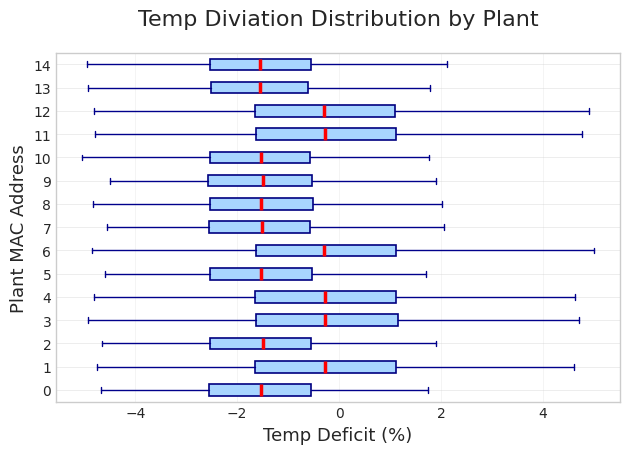

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# Optional: nicer style
plt.style.use('seaborn-v0_8-whitegrid')

# Create the figure
plt.figure(figsize=(14, 10))

# Correct and better boxplot: Soil Deficit by Plant
X.boxplot(
    column='temp_deviation',
    by='mac_id',
    vert=False,
    patch_artist=True,
    boxprops=dict(facecolor='#a8d5ff', edgecolor='navy', linewidth=1.2),
    medianprops=dict(color='red', linewidth=2.5),
    whiskerprops=dict(color='darkblue'),
    capprops=dict(color='darkblue'),
    flierprops=dict(marker='o', markerfacecolor='orange', markersize=4, alpha=0.6)
)

plt.title("Temp Diviation Distribution by Plant", fontsize=16, pad=20)
plt.suptitle("")
plt.xlabel("Temp Deficit (%)", fontsize=13)
plt.ylabel("Plant MAC Address", fontsize=13)


plt.xticks(rotation=0)
plt.grid(axis='x', alpha=0.3)

ax = plt.gca()
plt.tight_layout()
plt.show()